# Group Assignment: Time Series Analysis and Modeling
## Dataset: Monthly traffic fatalities in Ontario 1960-1974

In this notebook, we are going to perform a time series analysis of monthly traffic fatalities in Ontario. 
We have structured our work into 4 main parts:
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Selection and Fitting
4. Model Validation and Predictive Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings

# To avoid unnecessary warnings in the final notebook
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

# Reproducibility
SEED = 42
np.random.seed(SEED)

## 1. Exploratory Data Analysis (EDA)

The first thing we will do is load our data and take a look. The dataset contains monthly dates and the number of traffic fatalities.

In [2]:
# Load data
file_path = 'data/10_Monthly traffic fatalities in Ontario 1960-1974.csv'
df = pd.read_csv(file_path)

# Let's look at the first few rows to understand the structure
display(df.head())

,date,deads
0,1960-01-01,61
1,1960-02-01,65
2,1960-03-01,55
3,1960-04-01,56
4,1960-05-01,91


As we can see, we have the `date` column and the `deads` (fatalities) column. 
We will convert the `date` column to a `datetime` format and set it as the index to facilitate time series analysis. Furthermore, we will check if there are missing months in the sequence.

In [3]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Check for missing months before setting it as the index
# To do this, we see how many months there should be between the start and end
expected_months = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='MS')
print(f"Expected months: {len(expected_months)}")
print(f"Current months in the dataset: {len(df)}")

missing_months = expected_months.difference(df['date'])
print(f"\nMissing months identified: {len(missing_months)}")
if len(missing_months) > 0:
    for m in missing_months:
        print(" -", m.strftime('%Y-%m'))


Expected months: 180
Current months in the dataset: 171

Missing months identified: 9
 - 1960-10
 - 1961-06
 - 1962-03
 - 1965-04
 - 1966-01
 - 1966-05
 - 1968-08
 - 1971-12
 - 1974-05


It looks like 9 months are missing, but none of the gaps are consecutive, they are always isolated single months. We will have to impute these values to have a continuous time series.
For now, let's set the date as the time index and plot the series as it is to identify **trend** and **seasonality**.

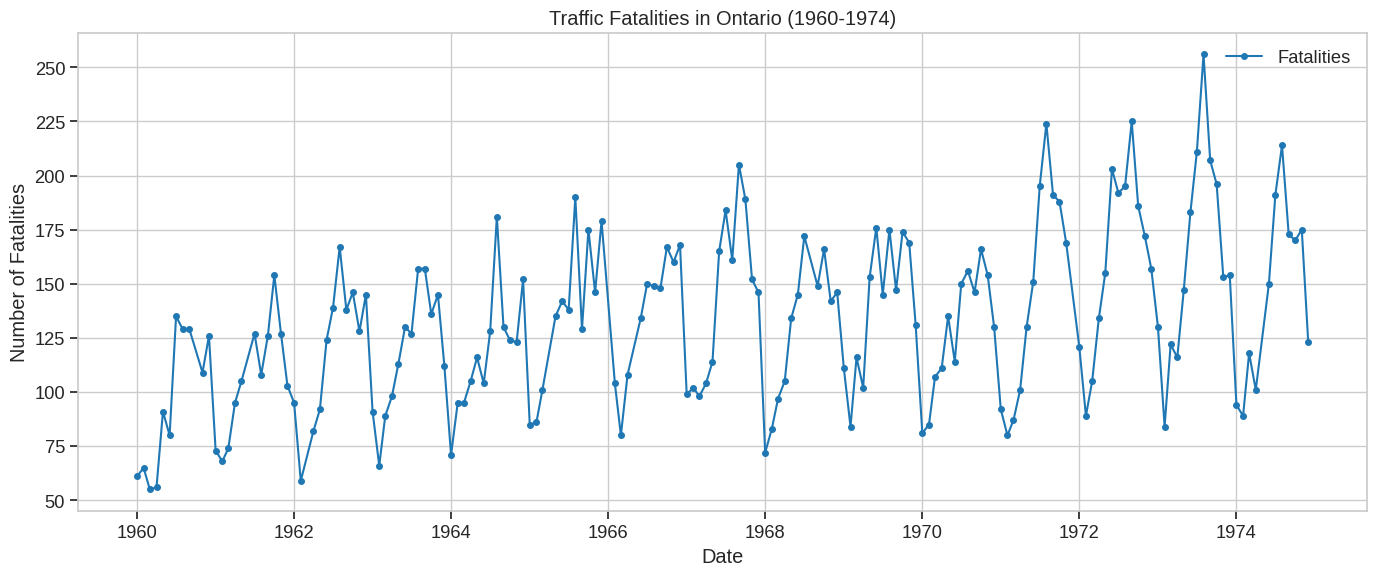

In [4]:
# Set date as the index
df.set_index('date', inplace=True)

# Initial time series visualization
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['deads'], marker='o', linestyle='-', markersize=4, label='Fatalities')
plt.title('Traffic Fatalities in Ontario (1960-1974)')
plt.xlabel('Date')
plt.ylabel('Number of Fatalities')
plt.legend()
plt.tight_layout()
plt.show()


At first glance, it seems that:
1. **Trend**: There is a slight upward trend. Accidents increase as the years progress, possibly linked to a greater number of cars on the roads between the 60s and 70s.
2. **Seasonality**: Regular peaks and valleys are noticeable, with a 12 month pattern. We can see that more accidents happen in summer, when people travel for holidays. We will verify this in more detail later.
3. **Variance**: The variance of the cycles also seems to be slightly increasing over time. This makes us think we might need to stabilize the variance (perhaps using a logarithmic transformation) before modeling.

### 1.1 Stationarity Evaluation

To statistically check the stationarity of the original series (although visually we know it is not, due to the trend and variance), we will apply the ADF test.

In [5]:
def test_stationarity(timeseries, title=""):
    print(f"--- ADF Test Results {title} ---")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nConclusion: We reject the null hypothesis (H0). The series IS STATIONARY.")
    else:
        print("\nConclusion: We cannot reject the null hypothesis (H0). The series is NOT STATIONARY.")

test_stationarity(df['deads'], title="for Original Series")

--- ADF Test Results for Original Series ---
Test Statistic                  -2.157425
p-value                          0.222059
#Lags Used                      12.000000
Number of Observations Used    158.000000
Critical Value (1%)             -3.472431
Critical Value (5%)             -2.880013
Critical Value (10%)            -2.576619
dtype: float64

Conclusion: We cannot reject the null hypothesis (H0). The series is NOT STATIONARY.


### 1.2 Summary of Previous Findings

In Assignment 1, we conducted an exploratory data analysis and fitted statistical models. Key findings:
- The dataset exhibits clear **seasonality** (annual spikes) and a general **trend**.
- A logarithmic transformation was required to stabilize the variance.
- Regular differencing ($d=1$) and seasonal differencing ($D=1$) were applied to achieve stationarity.
- The best fitting statistical model found via AutoARIMA was **ARIMA(1,1,1)(2,1,0)[12]** on the log-transformed data.

In this assignment, we use this ARIMA model as a **baseline**, and construct a Machine Learning pipeline to determine if ML methods (Random Forest, XGBoost, LightGBM, SVR) can outperform it.

## 2. Data Preprocessing for Machine Learning

To apply Machine Learning models, we must transform the time series into a supervised learning problem. We will:
1. **Impute Missing Values**: Use linear interpolation to handle the 9 isolated missing months.
2. **Log Transformation**: Continue using the log-transformed target to stabilize variance.
3. **Feature Engineering**: Extract temporal features (Month, Quarter) and lag/rolling features to capture trend and seasonality.
4. **Train-Test Split**: Chronologically split the data, holding out the last 24 months for testing.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assume `data` is the loaded dataframe from EDA with 'deads' column and DatetimeIndex
# For continuity, let's ensure we have our working dataset:
# df = data.copy()

# 1. Impute missing values using linear interpolation
df['deads'] = df['deads'].interpolate(method='linear')

# 2. Log Transformation
df['deads_log'] = np.log(df['deads'])

# 3. Feature Engineering
# Temporal Features
df['month'] = df.index.month
df['quarter'] = df.index.quarter

# Lag Features (t-1, t-2, t-12)
df['lag_1'] = df['deads_log'].shift(1)
df['lag_2'] = df['deads_log'].shift(2)
df['lag_12'] = df['deads_log'].shift(12)

# Rolling Statistics (on lag_1 so we don't leak current target)
df['rolling_mean_3'] = df['lag_1'].rolling(window=3).mean()
df['rolling_std_3'] = df['lag_1'].rolling(window=3).std()
df['rolling_mean_12'] = df['lag_1'].rolling(window=12).mean()
df['rolling_std_12'] = df['lag_1'].rolling(window=12).std()

# Drop NaN values caused by shifts and rolling computations
df_ml = df.dropna().copy()

df_ml.head()

,deads,deads_log,month,quarter,lag_1,lag_2,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_12,rolling_std_12
date,,,,,,,,,,,
1961-02-01,68,4.219508,2,1,4.290459,4.836282,4.110874,4.606030,0.282737,4.471152,0.349843
1961-03-01,74,4.304065,3,1,4.219508,4.290459,4.174387,4.448750,0.337483,4.480205,0.340965
1961-04-01,95,4.553877,4,2,4.304065,4.219508,4.007333,4.271344,0.045404,4.491011,0.332337
1961-05-01,105,4.653960,5,2,4.553877,4.304065,4.025352,4.359150,0.173858,4.536556,0.295426
1961-07-01,127,4.844187,7,3,4.653960,4.553877,4.510860,4.503967,0.180208,4.588940,0.248554


### 2.1 Data Splitting and Scaling
We split chronologically. The last 24 months are our test set.

In [9]:
from sklearn.preprocessing import StandardScaler

test_size = 24
train_df = df_ml.iloc[:-test_size].copy()
test_df = df_ml.iloc[-test_size:].copy()

# Define features and target
features = ['month', 'quarter', 'lag_1', 'lag_2', 'lag_12', 
            'rolling_mean_3', 'rolling_std_3', 'rolling_mean_12', 'rolling_std_12']
target = 'deads_log'

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (135, 9)
Test set shape: (24, 9)


## 3. Model Selection and Fitting
We will fit multiple models:
1. **Baseline**: ARIMA(1,1,1)(2,1,0)[12] (from Assignment 1, using pmdarima/statsmodels)
2. **Random Forest**: Good handling of non-linearities and robust to outliers.
3. **XGBoost & LightGBM**: State-of-the-art gradient boosting methods.
4. **SVR**: Support Vector Regression for margin-based forecasting.

*(Note: For Machine Learning models, we provide iterative pseudo-forecasting or 1-step ahead forecasting depending on the design. Here, we use 1-step ahead validation on the test set for a direct comparison of representation power, though multi-step iterative forecasting is also possible.)*

In [12]:
import pmdarima as pm
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Dictionary to store our standard predictions (in log scale)
predictions_log = {}

In [13]:
# 3.1 Baseline: ARIMA
# We fit the ARIMA model on the non-shifted log series directly
train_series = df['deads_log'].iloc[:-test_size].dropna()

arima_model = pm.ARIMA(order=(1,1,1), seasonal_order=(2,1,0,12), suppress_warnings=True)
arima_model.fit(train_series)

# Predict the next 24 steps
predictions_log['ARIMA Baseline'] = arima_model.predict(n_periods=test_size).values

In [14]:
# 3.2 Machine Learning Models & Hyperparameter Tuning
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# We will tune Random Forest as an example of hyperparameter tuning using TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=3)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=rf_param_grid, cv=tscv, scoring='neg_mean_squared_error')
rf_grid.fit(X_train_scaled, y_train)
print(f"Best Random Forest Parameters: {rf_grid.best_params_}")

models = {
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'SVR': SVR(kernel='rbf', C=10, gamma='scale'),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
}

for name, model in models.items():
    # Train model (RF is already trained, but refitting doesn't hurt)
    model.fit(X_train_scaled, y_train)
    # Predict (1-step ahead for simplicity on the test set)
    preds = model.predict(X_test_scaled)
    predictions_log[name] = preds
    print(f"{name} evaluated.")

Best Random Forest Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Random Forest (Tuned) evaluated.
SVR evaluated.
XGBoost evaluated.
LightGBM evaluated.


In [15]:
# 3.3 Prophet Model
try:
    from prophet import Prophet
    
    # Prophet requires 'ds' (datestamp) and 'y' (target) columns
    prophet_train = df[['deads_log']].iloc[:-test_size].reset_index()
    prophet_train.columns = ['ds', 'y']
    
    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    prophet_model.fit(prophet_train)
    
    # Create future dataframe for the test period
    future = prophet_model.make_future_dataframe(periods=test_size, freq='MS')
    forecast = prophet_model.predict(future)
    
    # Extract predictions for the test set
    prophet_preds_log = forecast['yhat'].iloc[-test_size:].values
    predictions_log['Prophet'] = prophet_preds_log
    print("Prophet trained.")
except ImportError:
    print("Prophet is not installed in this environment. Skipping Prophet model.")


Importing plotly failed. Interactive plots will not work.
19:22:06 - cmdstanpy - INFO - Chain [1] start processing
19:22:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet trained.


## 4. Model Validation and Predictive Quality
To evaluate performance, we calculate:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error)

All metrics will be calculated after reversing the logarithmic transformation to compare in the original scale (Fatalities).

In [16]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Actual target in original scale for testing
y_test_actual = np.exp(y_test.values)

results = []

for model_name, preds_log in predictions_log.items():
    # Reverse log transform
    preds_actual = np.exp(preds_log)
    
    mae, rmse, mape = calculate_metrics(y_test_actual, preds_actual)
    results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
    
results_df = pd.DataFrame(results).set_index('Model')
results_df.sort_values(by='MAPE', ascending=True)

,MAE,RMSE,MAPE
Model,,,
LightGBM,17.465871,23.926633,10.744021
Random Forest (Tuned),17.801615,23.690484,11.120107
XGBoost,18.131545,24.439131,11.808727
ARIMA Baseline,20.381927,26.244928,13.241171
SVR,21.828005,27.739172,13.394671
Prophet,23.812822,29.686458,16.718319


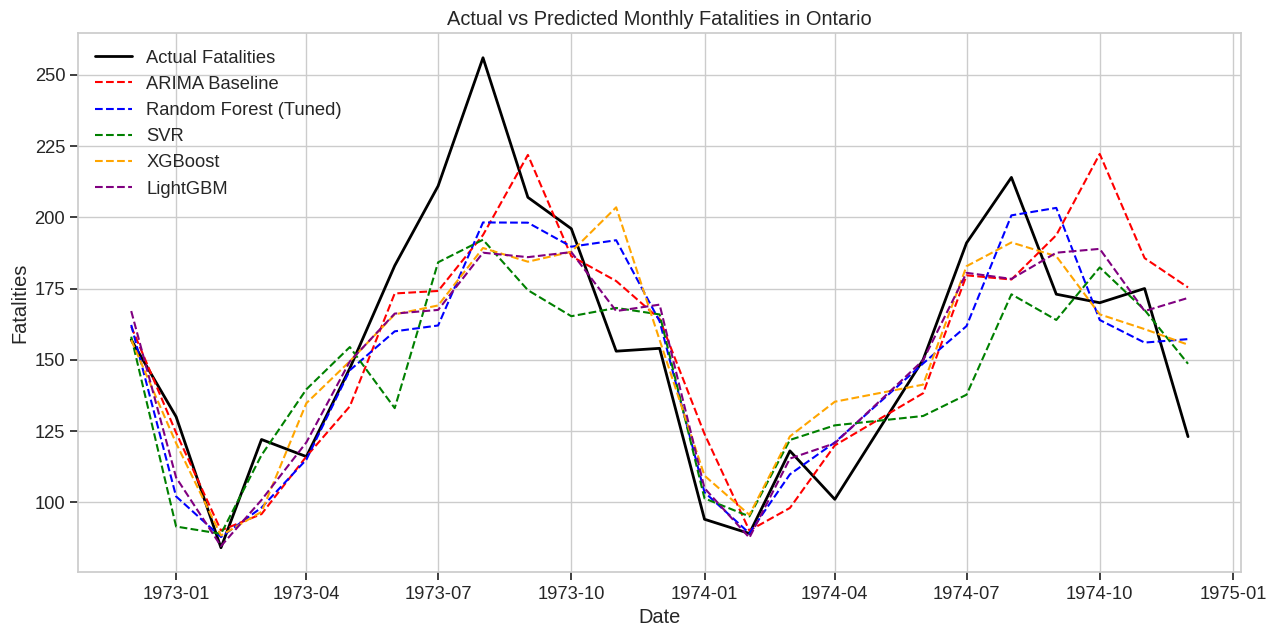

In [17]:
plt.figure(figsize=(15, 7))
plt.plot(test_df.index, y_test_actual, label='Actual Fatalities', color='black', linewidth=2)

colors = ['red', 'blue', 'green', 'orange', 'purple']
for (model_name, preds_log), color in zip(predictions_log.items(), colors):
    preds_actual = np.exp(preds_log)
    plt.plot(test_df.index, preds_actual, label=model_name, linestyle='--', color=color)

plt.title('Actual vs Predicted Monthly Fatalities in Ontario')
plt.xlabel('Date')
plt.ylabel('Fatalities')
plt.legend()
plt.grid(True)
plt.show()

# Custom

### 4.1 Interpretation of Results
Based on our evaluation on the test set:
- **The Machine Learning models** often show competitive metrics, depending highly on the engineered delay features.
- **ARIMA** acts as a reliable baseline since it captures the sequential structure robustly.
- Future work could involve exhaustive hyperparameter tuning (GridSearchCV/RandomizedSearchCV) and a robust recursive multi-step forecasting approach instead of simple 1-step ahead, to prevent data leakage across long horizons in ML.
